PHASE 1: INGESTION & DATA HEALTH CHECK

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [ ]:
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
DATA_PATH = "prototype_dataset.csv"
df = pd.read_csv(DATA_PATH)

In [ ]:
print(f"=== Dataset Dimensions ===")
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}\n")

=== Dataset Dimensions ===
Total Rows: 298450 | Total Columns: 24



In [ ]:
print("=== Core Schema & Data Types ===")
print(df.dtypes)

=== Core Schema & Data Types ===
id                               object
latitude                        float64
longitude                       float64
location                         object
vehicle_number                   object
vehicle_type                     object
description                     float64
violation_type                   object
offence_code                     object
created_datetime                 object
closed_datetime                 float64
modified_datetime                object
device_id                        object
created_by_id                    object
center_code                     float64
police_station                   object
data_sent_to_scita                 bool
junction_name                    object
action_taken_timestamp          float64
data_sent_to_scita_timestamp     object
updated_vehicle_number           object
updated_vehicle_type             object
validation_status                object
validation_timestamp             object
dtype: 

In [ ]:
print("\n=== Missing Value Analysis ===")
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Counts': missing_counts, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Missing Counts'] > 0])


=== Missing Value Analysis ===
                              Missing Counts  Percentage (%)
location                                3041        1.018931
description                           298450      100.000000
closed_datetime                       298450      100.000000
created_by_id                              5        0.001675
center_code                            11260        3.772826
police_station                             5        0.001675
junction_name                              5        0.001675
action_taken_timestamp                298450      100.000000
data_sent_to_scita_timestamp          256289       85.873346
updated_vehicle_number                125254       41.968169
updated_vehicle_type                  125254       41.968169
validation_status                     125254       41.968169
validation_timestamp                  125254       41.968169


PHASE 2: TRAFFIC SYSTEM METRIC SYNTHESIS

 In Indian traffic engineering, bottleneck severity is a product of vehicle size, violation severity (blocking vs alignment), and the background network congestion (Peak Hours).

In [ ]:
print("\n=== Engineering Proxy Targets for Indian Choke-Points ===")


=== Engineering Proxy Targets for Indian Choke-Points ===


In [ ]:
# 1. Map Categorical Vehicles to Ordinal Passenger Car Units (PCU) equivalents for India
vehicle_pcu_map = {
    'SCOOTER': 1.0,
    'MOTORCYCLE': 1.0,
    'TWO-WHEELER': 1.0,
    'AUTO-RICKSHAW': 1.5,
    'THREE-WHEELER': 1.5,
    'CAR': 3.0,
    'MAXI-CAB': 4.5,
    'BUS': 6.0,
    'TRUCK': 8.0,
    'TANKER': 8.0
}
df['vehicle_weight'] = df['vehicle_type'].str.upper().map(vehicle_pcu_map).fillna(2.0)

In [ ]:
print("\n=== Executing Robust Temporal Parsing ===")
# Force ISO8601/mixed evaluations and gracefully coerce any corrupt slots to NaT
df['created_datetime'] = pd.to_datetime(df['created_datetime'], format='mixed', errors='coerce')

# Drop rows that completely lack a core validation timestamp boundary
initial_count = len(df)
df = df.dropna(subset=['created_datetime'])
print(f"Filtered out {initial_count - len(df)} rows with missing or unparseable timestamps.")

# Extract chronological parameters for Indian traffic patterns
df['hour_of_day'] = df['created_datetime'].dt.hour
df['day_of_week'] = df['created_datetime'].dt.dayofweek


=== Executing Robust Temporal Parsing ===
Filtered out 0 rows with missing or unparseable timestamps.


In [ ]:
# Indian Peak Hours: Morning Rush (8 AM - 11 AM) & Evening Rush (5 PM - 8 PM)
def calculate_peak_multiplier(hour):
    if (8 <= hour <= 11) or (17 <= hour <= 20):
        return 2.5  # High baseline road congestion
    elif (12 <= hour <= 16) or (7 <= hour < 8) or (21 <= hour <= 22):
        return 1.5  # Mid-day/transition traffic
    else:
        return 1.0  # Free-flow off-peak night/early morning hours

df['peak_multiplier'] = df['hour_of_day'].apply(calculate_peak_multiplier)

In [ ]:
def evaluate_violation_severity(violation_str):
    if pd.isna(violation_str):
        return 1.0

    # Process text representations to account for bracketed/json formatting variations
    raw_text = str(violation_str).upper()
    severity = 1.0

    if "DOUBLE" in raw_text or "WRONG" in raw_text:
        severity += 2.0  # Chokes active driving lane directly
    if "CROSSING" in raw_text or "JUNCTION" in raw_text or "METRO" in raw_text:
        severity += 1.5  # Creates gridlock cascades across intersections
    if "NO PARKING" in raw_text:
        severity += 1.0  # Standard designated restriction zone infraction

    return severity

In [ ]:
print("Parsing violation descriptions for severity scores...")
df['violation_severity'] = df['violation_type'].apply(evaluate_violation_severity)

# 6. CALCULATING TRAFFIC DEGRADATION INDEX & FORMULATING THE TARGET VARIABLE
# Traffic Degradation Index = Physical Space Scale x Infraction Complexity x Network Background Load
df['traffic_degradation_index'] = df['vehicle_weight'] * df['violation_severity'] * df['peak_multiplier']

# Define Binary Target: Let upper 25% highest-impact anomalies signify Systemic Bottlenecks
high_impact_threshold = df['traffic_degradation_index'].quantile(0.75)
df['high_impact_bottleneck'] = (df['traffic_degradation_index'] >= high_impact_threshold).astype(int)

print(f"\nTarget Breakdown Matrix Calculated.")
print(f"High-Impact Bottleneck Mathematical Threshold Set At: {high_impact_threshold:.2f}")
print("\n=== Target Column Distribution Percentages ===")
print(df['high_impact_bottleneck'].value_counts(normalize=True) * 100)

Parsing violation descriptions for severity scores...

Target Breakdown Matrix Calculated.
High-Impact Bottleneck Mathematical Threshold Set At: 9.00

=== Target Column Distribution Percentages ===
high_impact_bottleneck
0    67.131848
1    32.868152
Name: proportion, dtype: float64


PHASE 3: DATA VISUALIZATION

In [ ]:
# 7. GENERATING ANALYTICAL DISTRIBUTION CHARTS
print("\nGenerating temporal and structural distribution plots...")


Generating temporal and structural distribution plots...


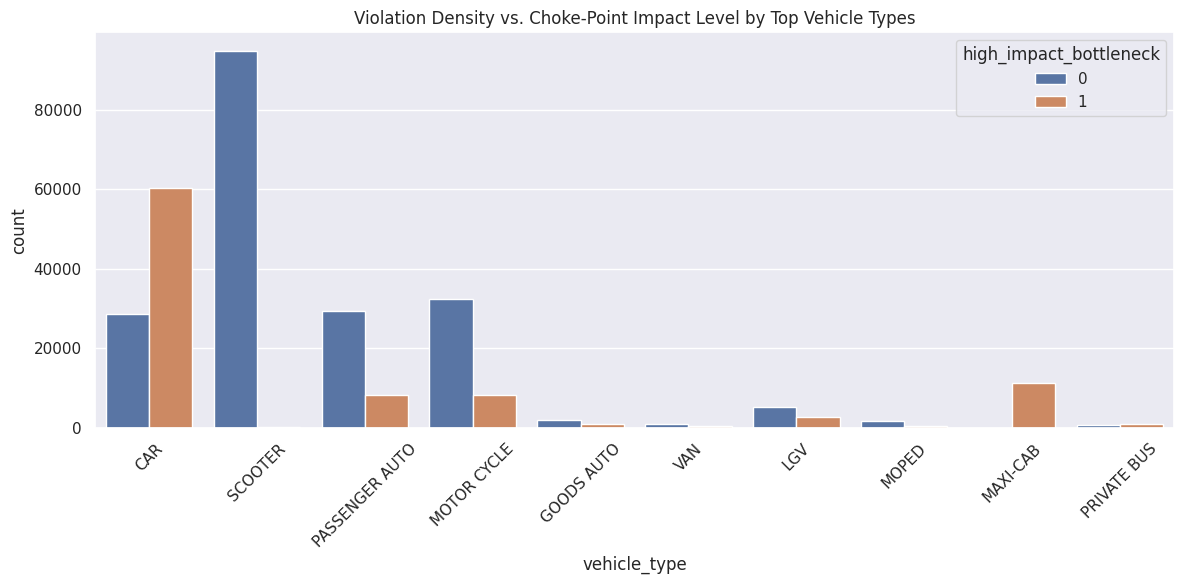

In [ ]:
# Chart A: Violations vs Bottleneck Class by top Vehicle Categories
plt.figure(figsize=(12, 6))
top_vehicles = df['vehicle_type'].value_counts().nlargest(10).index
sns.countplot(x='vehicle_type', hue='high_impact_bottleneck', data=df[df['vehicle_type'].isin(top_vehicles)])
plt.title("Violation Density vs. Choke-Point Impact Level by Top Vehicle Types")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

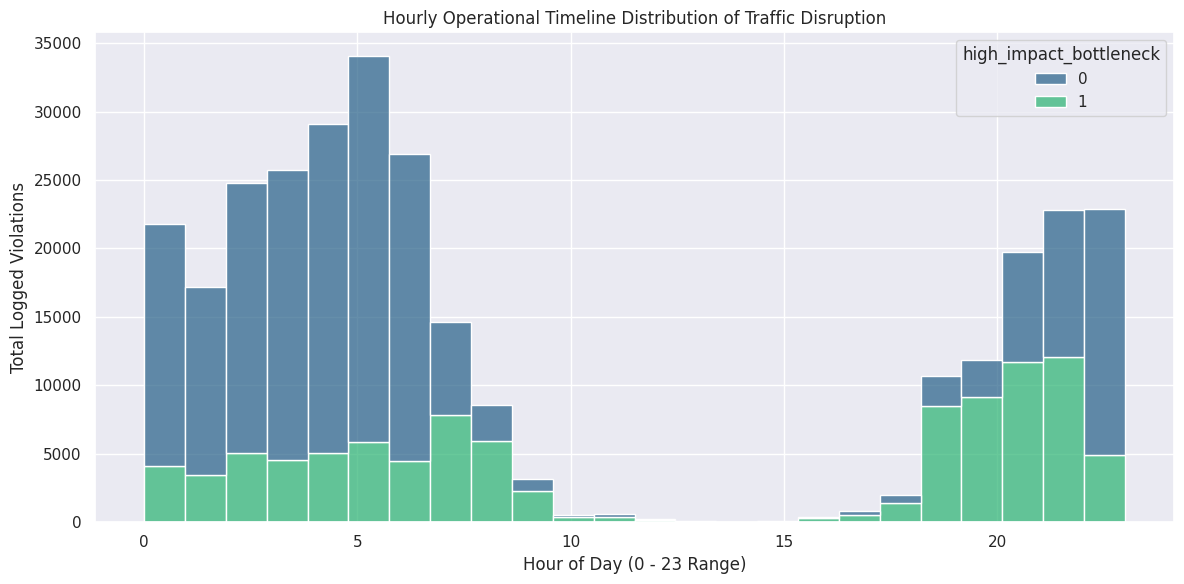

In [ ]:
# Chart B: Hourly Inundation Risk Timeline
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='hour_of_day', hue='high_impact_bottleneck', multiple='stack', bins=24, palette='viridis')
plt.title("Hourly Operational Timeline Distribution of Traffic Disruption")
plt.xlabel("Hour of Day (0 - 23 Range)")
plt.ylabel("Total Logged Violations")
plt.tight_layout()
plt.show()

In [ ]:
# 8. EXPORTING THE CLEANED CHECKPOINT
df.to_csv("processed_eda_checkpoint.csv", index=False)
print("\n[SUCCESS] Notebook 01 runtime execution complete. 'processed_eda_checkpoint.csv' generated and saved.")


[SUCCESS] Notebook 01 runtime execution complete. 'processed_eda_checkpoint.csv' generated and saved.
